# Relatório de Análise e Métricas - Camada Gold
Este notebook responde às perguntas de negócio estipuladas utilizando dados limpos da Camada Silver e tabelas/views agregadas da Camada Gold.

In [2]:
#Importações e Configuração de Estilo#

import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import MYSQL_CONFIG

# Configurações globais de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

PARTE 1: Perguntas Diretas na Camada Silver (Consultas SQL + Gráficos)

Pergunta 1 — Os 5 órgãos com maior custo total?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\1486683639.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_1 = pd.read_sql(query_1, conn)


--- Os 5 órgãos com maior custo total ---


,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\1486683639.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_1 = pd.read_sql(query_1, conn)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\1486683639.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_1, x="custo_total_mi", y="nome_orgao_superior", palette="viridis")


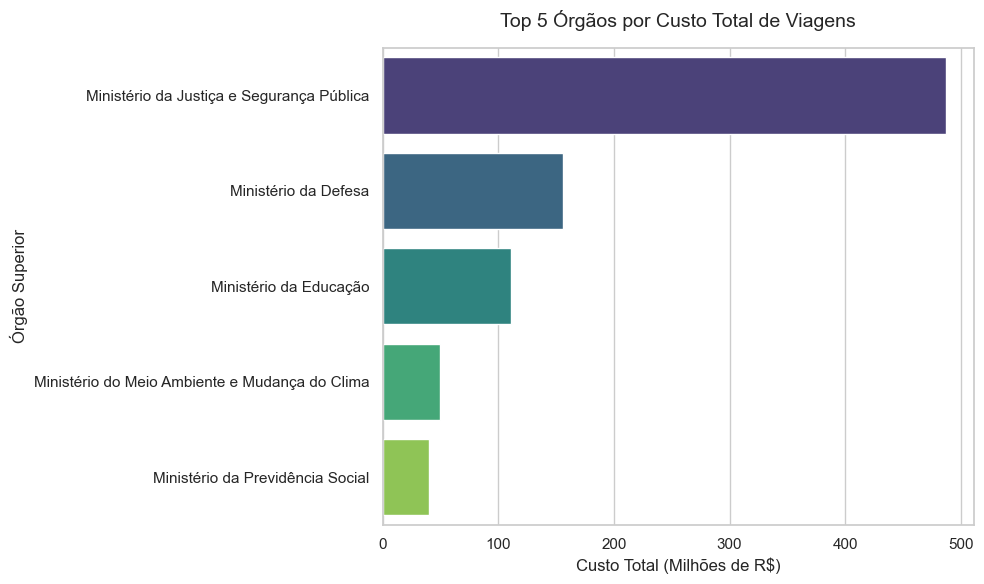

In [ ]:
# Conexão
conn = mysql.connector.connect(**MYSQL_CONFIG)

query_1 = """
    SELECT nome_orgao_superior, SUM(valor_total) AS custo_total 
    FROM silver_viagem 
    GROUP BY nome_orgao_superior 
    ORDER BY custo_total DESC 
    LIMIT 5;
"""
df_1 = pd.read_sql(query_1, conn)

# Tabela
print("--- Os 5 órgãos com maior custo total ---")
display(df_1)


# Conexão e query
df_1 = pd.read_sql(query_1, conn)

# Cria uma coluna auxiliar com o valor em milhões
df_1["custo_total_mi"] = df_1["custo_total"] / 1_000_000

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_1, x="custo_total_mi", y="nome_orgao_superior", palette="viridis")

# Ajustes de títulos e eixos claros
plt.title("Top 5 Órgãos por Custo Total de Viagens", fontsize=14, pad=15)
plt.xlabel("Custo Total (Milhões de R$)", fontsize=12)
plt.ylabel("Órgão Superior", fontsize=12)
plt.tight_layout()
plt.show()

Pergunta 2 — Os 3 destinos com maior custo médio por viagem?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\647159072.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_2 = pd.read_sql(query_2, conn)
C:\Users\Usuario\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Usuario\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


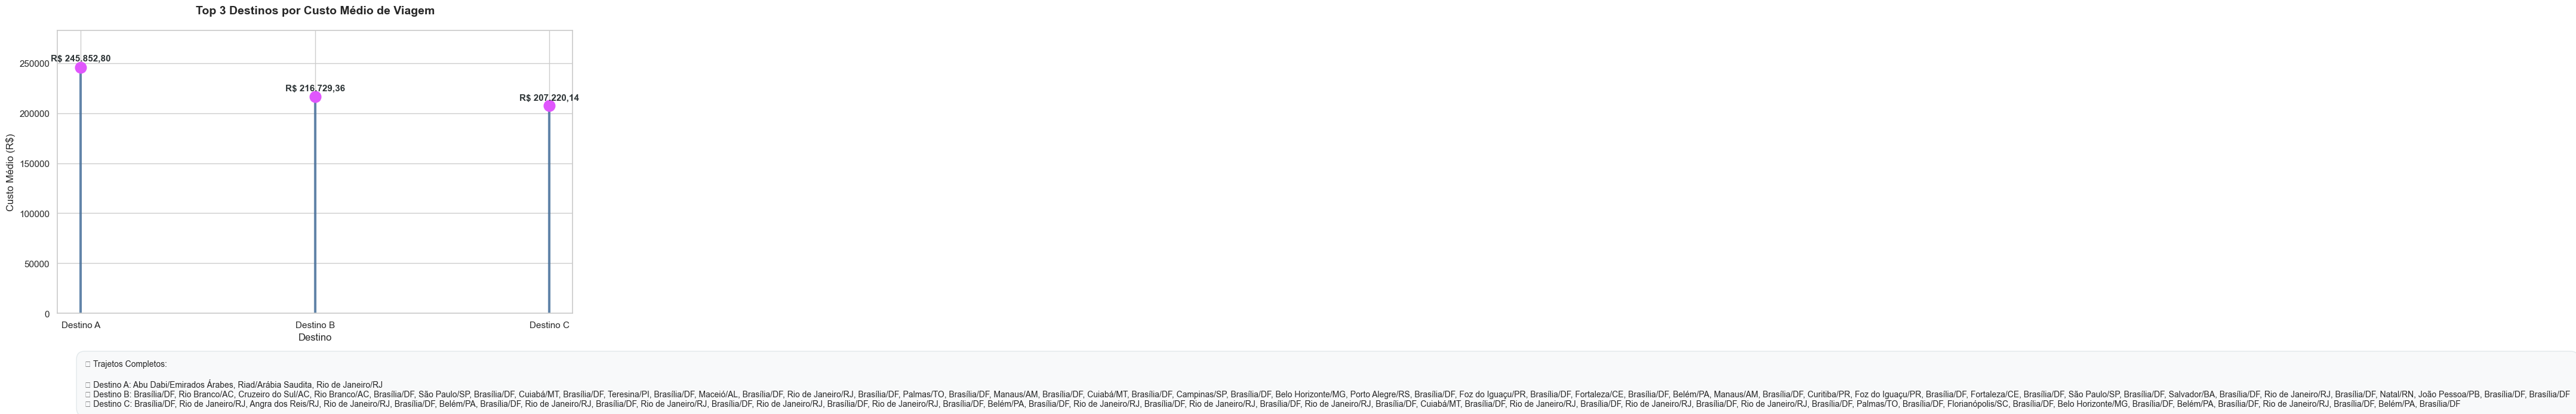

In [10]:
query_2 = """
    SELECT destinos, AVG(valor_total) AS custo_medio 
    FROM silver_viagem 
    GROUP BY destinos 
    ORDER BY custo_medio DESC 
    LIMIT 3;
"""
df_2 = pd.read_sql(query_2, conn)

# Criamos rótulos curtos para o eixo X
df_2["rotulo"] = ["Destino A", "Destino B", "Destino C"]

# Tabela auxiliar para podermos mapear na legenda
mapeamento_destinos = dict(zip(df_2["rotulo"], df_2["destinos"]))

# Configuração do gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Desenha as linhas verticais (cabos do pirulito)
ax.vlines(x=df_2["rotulo"], ymin=0, ymax=df_2["custo_medio"], color='#2b5c8f', alpha=0.7, linewidth=3)

# 2. Desenha os círculos no topo (doces do pirulito)
ax.scatter(x=df_2["rotulo"], y=df_2["custo_medio"], color='#e056fd', s=180, zorder=3)

# Adiciona os valores monetários exatos acima de cada pirulito
for i, valor in enumerate(df_2["custo_medio"]):
    ax.text(i, valor + (valor * 0.02), f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."), 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2d3436')

# Configurações de títulos e eixos
plt.title("Top 3 Destinos por Custo Médio de Viagem", fontsize=14, pad=20, fontweight="bold")
plt.ylabel("Custo Médio (R$)", fontsize=12)
plt.xlabel("Destino", fontsize=12)

# Ajuste do limite do eixo Y para que o texto acima do círculo não seja cortado
ax.set_ylim(0, df_2["custo_medio"].max() * 1.15)

# --- CRIAÇÃO DA LEGENDA PERSONALIZADA ---
# Criamos uma caixa de texto explicativa simulando uma legenda técnica
texto_legenda = "📍 Trajetos Completos:\n\n" + "\n".join([f"🔹 {rotulo}: {trajeto}" for rotulo, trajeto in mapeamento_destinos.items()])

# Posiciona a caixa explicativa abaixo do gráfico de forma organizada
plt.figtext(0.15, -0.15, texto_legenda, fontsize=10, ha="left",
            bbox=dict(boxstyle="round,pad=1", facecolor="#f8f9fa", edgecolor="#dfe6e9", alpha=0.9))

plt.tight_layout()
plt.show()

Pergunta 3 — A viagem de maior duração e seu custo total?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\3867994061.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_3 = pd.read_sql(query_3, conn)


--- Viagem de maior duração ---


,id_viagem,nome_viajante,destinos,duracao_dias,valor_total
0,0000000000020793594,Informações protegidas por sigilo,Informações protegidas por sigilo,378,120650.0


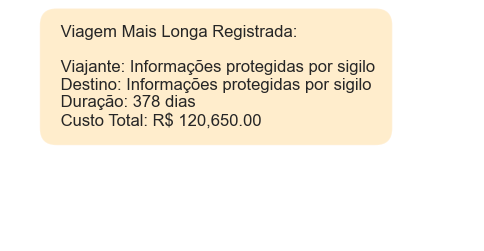

In [12]:
query_3 = """
    SELECT id_viagem, nome_viajante, destinos, duracao_dias, valor_total 
FROM silver_viagem 
WHERE duracao_dias > 0 
  AND valor_total > 0
  AND data_inicio IS NOT NULL 
  AND data_fim IS NOT NULL
ORDER BY duracao_dias DESC, valor_total DESC
LIMIT 1;
"""
df_3 = pd.read_sql(query_3, conn)

# Tabela
print("--- Viagem de maior duração ---")
display(df_3)

# Visualização de Destaque
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')
texto = (
    f" Viagem Mais Longa Registrada:\n\n"
    f" Viajante: {df_3['nome_viajante'].iloc[0]}\n"
    f" Destino: {df_3['destinos'].iloc[0]}\n"
    f" Duração: {df_3['duracao_dias'].iloc[0]} dias\n"
    f" Custo Total: R$ {df_3['valor_total'].iloc[0]:,.2f}"
)
ax.text(0.1, 0.5, texto, fontsize=12, bbox=dict(facecolor='orange', alpha=0.2, boxstyle='round,pad=1'))
plt.show()

PARTE 2: Perguntas Utilizando a Camada Gold Agregada (View / Tabela)

In [ ]:
Pergunta 4 — Qual o tipo de pagamento com maior valor médio?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\1508621271.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_4 = pd.read_sql(query_4, conn)


--- Valor Médio por Tipo de Pagamento ---


,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.280299
1,PASSAGEM,1878.344393
2,Serviço correlato: seguro,447.514653
3,RESTITUIÇÃO,245.702610


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\1508621271.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_4, x="valor_medio", y="tipo_pagamento", palette="Blues_r")


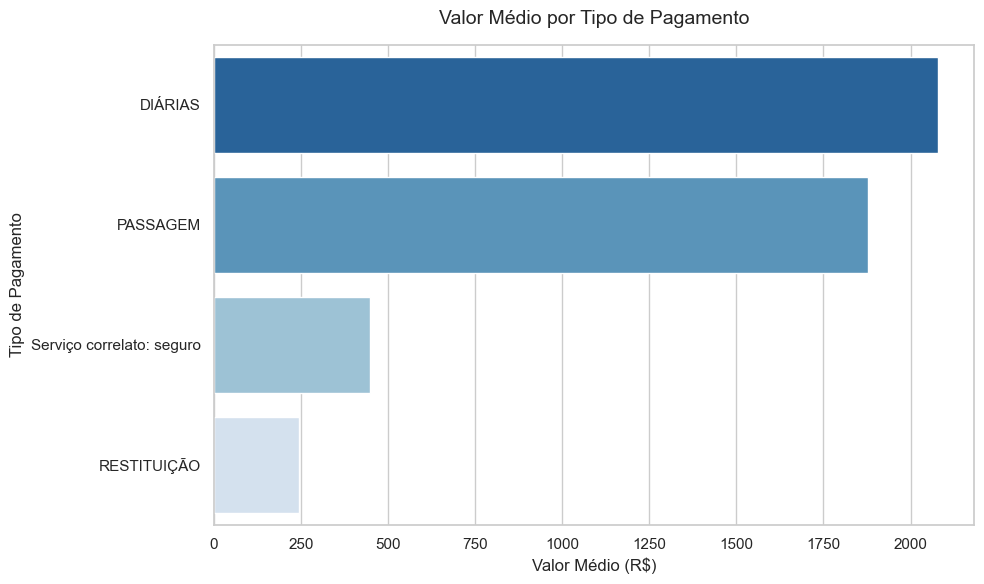

In [13]:
query_4 = """
    SELECT tipo_pagamento, AVG(valor) AS valor_medio 
    FROM silver_pagamento 
    GROUP BY tipo_pagamento 
    ORDER BY valor_medio DESC;
"""
df_4 = pd.read_sql(query_4, conn)

print("--- Valor Médio por Tipo de Pagamento ---")
display(df_4)

plt.figure()
sns.barplot(data=df_4, x="valor_medio", y="tipo_pagamento", palette="Blues_r")
plt.title("Valor Médio por Tipo de Pagamento", fontsize=14, pad=15)
plt.xlabel("Valor Médio (R$)", fontsize=12)
plt.ylabel("Tipo de Pagamento", fontsize=12)
plt.tight_layout()
plt.show()

Pergunta 5 — Qual o meio de transporte mais usado nos trechos e qual UF de destino aparece mais?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\2024327269.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5a = pd.read_sql(query_5a, conn)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\2024327269.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_5b = pd.read_sql(query_5b, conn)


,meio_transporte,quantidade
0,None,763349


,destino_uf,ocorrencias
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\2024327269.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df_5a, x="quantidade", y="meio_transporte", palette="crest")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_9400\2024327269.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df_5b, x="ocorrencias", y="destino_uf", palette="flare")


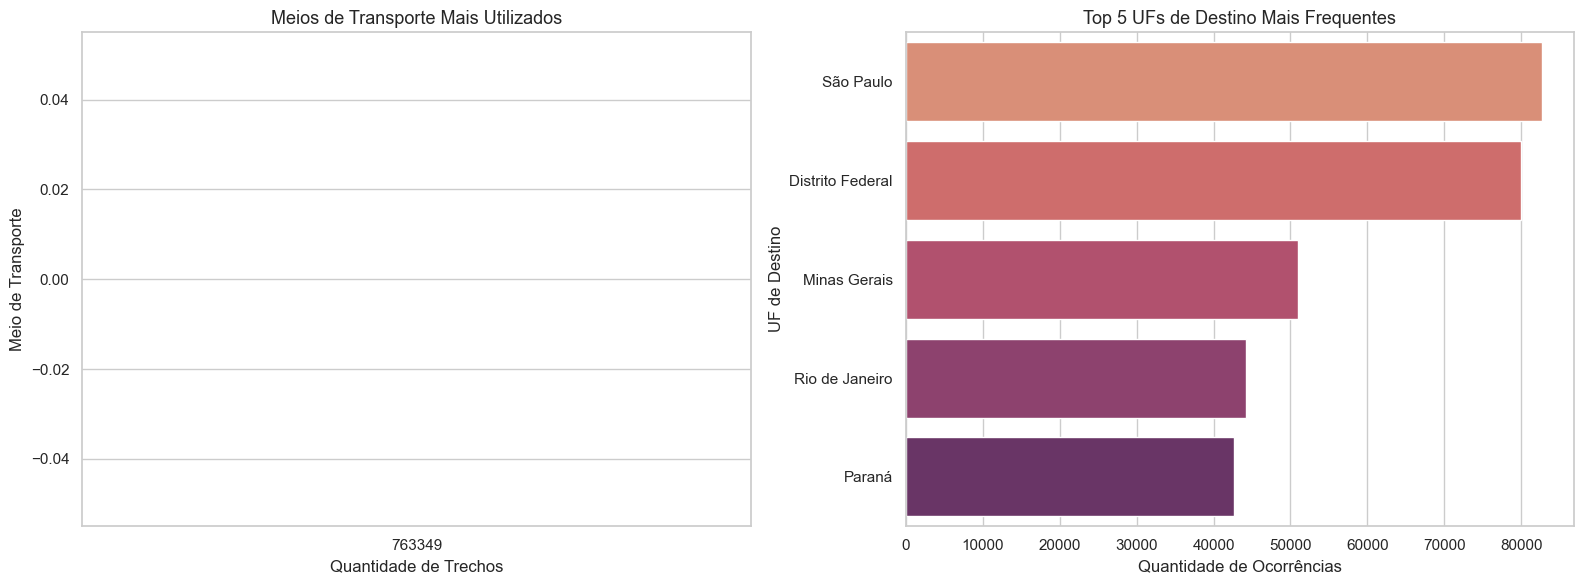

In [14]:
# Consulta 5A: Meio de Transporte
query_5a = """
    SELECT meio_transporte, COUNT(*) AS quantidade 
    FROM silver_trecho 
    GROUP BY meio_transporte 
    ORDER BY quantidade DESC;
"""
df_5a = pd.read_sql(query_5a, conn)

# Consulta 5B: UFs de Destino
query_5b = """
    SELECT destino_uf, COUNT(*) AS ocorrencias 
    FROM silver_trecho 
    WHERE destino_uf IS NOT NULL AND destino_uf != ''
    GROUP BY destino_uf 
    ORDER BY ocorrencias DESC 
    LIMIT 5;
"""
df_5b = pd.read_sql(query_5b, conn)

display(df_5a)
display(df_5b)

# Gráfico Combinado (Subplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], data=df_5a, x="quantidade", y="meio_transporte", palette="crest")
axes[0].set_title("Meios de Transporte Mais Utilizados", fontsize=13)
axes[0].set_xlabel("Quantidade de Trechos")
axes[0].set_ylabel("Meio de Transporte")

sns.barplot(ax=axes[1], data=df_5b, x="ocorrencias", y="destino_uf", palette="flare")
axes[1].set_title("Top 5 UFs de Destino Mais Frequentes", fontsize=13)
axes[1].set_xlabel("Quantidade de Ocorrências")
axes[1].set_ylabel("UF de Destino")

plt.tight_layout()
plt.show()

In [ ]:
Pergunta 6 — Qual órgão pagou mais no total? (Consultando nossa View Gold)

In [ ]:
# Query utilizando a VIEW AGREGADA GOLD criada no Passo 2
query_6 = """
    SELECT nome_orgao_superior, custo_total_viagens 
    FROM gold_view_custo_orgao 
    ORDER BY custo_total_viagens DESC 
    LIMIT 1;
"""
df_6 = pd.read_sql(query_6, conn)

print("--- Órgão Líder em Custo de Viagens ---")
display(df_6)

# Fecha a conexão ao finalizar as análises
conn.close()